# ECS8055 AI for Health — ICW Part 2: Classification of Medulloblastoma Subtypes

### Academic Integrity Declaration

- Student Number: **40466218** 
- Name: **Conor Brown**
- Module: **ECS8055**
- Date: **17/4/2026**

By submitting this work, I declare that:
1. I have read and understood the University regulations relating to academic offences, including
collusion and plagiarism:
http://www.qub.ac.uk/directorates/AcademicStudentAffairs/AcademicAffairs/GeneralRegulations/
Procedures/ProceduresforDealingwithAcademicOffences/
2. The submission is my own original work and no part of it has been submitted for any other
assignment, except as otherwise permitted.
3. All sources used, including Generated-AI tools, published or unpublished, have been fully
acknowledged.
4. I give my consent for the work to be scanned using plagiarism detection software.

## Summary

This notebook developed a Support Vector Classifier for DNA methylation-based classification of medulloblastoma into 8 molecular subtypes using 16 NMF-derived features. Through systematic hyperparameter optimisation across 5 iterations with 10-fold stratified cross-validation, the model was progressively refined from initial parameters to an optimised configuration. This improved on the macro-F1 benchmark set by Abid and Rafiee (2024) on the HM450 (0.97 vs 0.94) and EPIC test set (0.94 vs 0.93).

### Key Findings

1. **SVC outperformed KNN** as the primary classifier, validating the choice of a margin-based approach over purely distance-based classification for this dataset. The polynomial/RBF kernel captures the non-linear decision boundaries between subtypes, particularly in the overlapping Group 3/4 region.

2. **Class imbalance handling** was critical. With subtype 1 (WNT) having only 51 samples compared to 347 for subtype 8 (Group4-B), the `class_weight='balanced'` parameter (which re-weights the SVM hinge loss inversely to class frequency) ensured that minority classes were not ignored by the classifier.

3. **Cross-platform generalisability** was demonstrated by applying the trained model to 97 EPIC array samples projected through the same NMF pipeline. An F1 score of 0.94 on the held-out test set is a strong indicator of generalisibilty.

### Limitations

1. **Data leakage in NMF projection:** The NMF decomposition in Part 1 was fitted on all 1,370 HM450 samples before the train/test split. This means the test set's NMF features are not fully independent of the training data: the NMF basis vectors (H matrix) were influenced by test set samples. This may slightly inflate test metrics. A more rigorous approach would fit NMF on the training set only and project the test set.

2. **Small minority classes:** Subtype 1 (WNT) has only ~41 training samples after the 80/20 split. With 10-fold CV, each fold has ~4 WNT samples, making per-fold estimates for this class highly variable. The macro-averaged F1 gives equal weight to all classes, which means WNT performance disproportionately affects the overall metric.

3. **Biological continuum:** Medulloblastoma subtypes, particularly within the Group 3/4 spectrum, exist on a biological continuum rather than as discrete categories (Sharma et al., 2019; Northcott et al., 2017). Some "misclassifications" may reflect genuine biological ambiguity rather than model failure; samples near subtype boundaries may be legitimately intermediate.


### Error Analysis

Most of the misclassified samples are better interpreted as biologically ambiguous boundary cases than as arbitrary model failures. This is particularly appropriate for the Group 3/Group 4 errors, because modern consensus work has shown that these tumours do not always form sharply separated molecular entities. Rather, several of the eight consensus subtypes occupy intermediate positions along a broader Group 3/Group 4 continuum, reflecting shared developmental and epigenetic features rather than fully discrete classes (Sharma et al., 2019). 

This interpretation is further supported by RNA-based analyses, which suggest that medulloblastoma subtypes can preserve overlapping transcriptional programs and lineage relationships even when assigned to different consensus classes, making some borderline cases biologically expected rather than purely technical errors (Robinson et al., 2022).

This interpretation is especially relevant for `GSM3877746`, which was misclassified in the same direction on both HM450 and EPIC data, suggesting a stable subtype-adjacent profile rather than a split-specific anomaly. Similarly, the SHH-related misclassifications are consistent with recognised intragroup heterogeneity, where neighbouring SHH states may retain partially overlapping methylation signatures and therefore become difficult to separate perfectly after dimensionality reduction. 

More broadly, this pattern is consistent with the wider validation literature, which emphasises that high-dimensional methylation classifiers must contend not only with class imbalance and technical variation, but also with genuine biological overlap and indeterminate cases near subtype boundaries (Capper et al., 2018). 

Taken together, these results suggest that the observed errors are more appropriately understood as evidence of subtype adjacency, mixed biological states, and decision-boundary sensitivity in reduced NMF space, rather than as simple classifier breakdown.

## 0. Setup

In [1]:
# Import key libraries, set random seed, and configure plotting for a consistent style

from joblib import load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    learning_curve, validation_curve, cross_val_score, cross_validate
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    balanced_accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 40466218
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.figsize'] = (10, 6)

SUBTYPE_NAMES = {
    1: 'WNT', 2: 'SHH-A', 3: 'SHH-B', 4: 'SHH-C',
    5: 'Group3-A', 6: 'Group3-B', 7: 'Group4-A', 8: 'Group4-B'
}

PATHS = {
    'hm450_csv': '40466218_Conor_Brown_ECS8055_ICW_010226.csv',
    'a1_nmf_config': 'hm450_nmf_pipeline.joblib',
    'epic_parquet': 'mice_imputed_epic.parquet',
}


In [2]:
# Reusable helpers for labelling, metrics, and plotting

def subtype_labels(classes, *, multiline=False):
    """Format class ids with SUBTYPE_NAMES, e.g. '1 (WNT)' or two-line tick labels."""
    if multiline:
        return [f"{s}\n{SUBTYPE_NAMES[s]}" for s in classes]
    return [f"{s} ({SUBTYPE_NAMES[s]})" for s in classes]


def metrics_dict(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
    }


def print_metrics(y_true, y_pred, title):
    print(f"--- {title} ---")

    METRIC_LABELS = {
    'accuracy': 'Accuracy',
    'balanced_accuracy': 'Balanced Accuracy',
    'f1_macro': 'F1 (macro)',
    'f1_weighted': 'F1 (weighted)'
    }
    
    for key, val in metrics_dict(y_true, y_pred).items():
        print(f"{METRIC_LABELS[key] + ':':<19}{val:.4f}")
    classes = sorted(np.unique(np.concatenate([np.asarray(y_true), np.asarray(y_pred)])))
    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        labels=classes,
        target_names=subtype_labels(classes),
        ))


def plot_grid_heatmap(results_df, ax, mask=None, fmt='.3f', vmin=None, vmax=None, title=''):
    data = results_df if mask is None else results_df[mask]
    pivot = data.pivot_table(values='mean_test_score', index='param_C',
                             columns='param_gamma', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap='YlOrRd',
                ax=ax, vmin=vmin, vmax=vmax)
    ax.set(xlabel='gamma', ylabel='C', title=title)


def plot_confusion(y_true, y_pred, classes, ax, *, title='', cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    ticks = subtype_labels(classes, multiline=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=ticks, yticklabels=ticks, cbar=False)
    ax.set(xlabel='Predicted Subtype', ylabel='True Subtype', title=title)


ALL_SUBTYPES = sorted(SUBTYPE_NAMES.keys())
COLORS = sns.color_palette('colorblind', len(ALL_SUBTYPES))


In [3]:
# Load HM450 CSV and preview the data

df = pd.read_csv(PATHS['hm450_csv'])
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()


Shape: (1370, 18)

Data types:
gsm         object
NMF_1      float64
NMF_2      float64
NMF_3      float64
NMF_4      float64
NMF_5      float64
NMF_6      float64
NMF_7      float64
NMF_8      float64
NMF_9      float64
NMF_10     float64
NMF_11     float64
NMF_12     float64
NMF_13     float64
NMF_14     float64
NMF_15     float64
NMF_16     float64
Subtype      int64
dtype: object

First 5 rows:


,gsm,NMF_1,NMF_2,NMF_3,NMF_4,NMF_5,NMF_6,NMF_7,NMF_8,NMF_9,NMF_10,NMF_11,NMF_12,NMF_13,NMF_14,NMF_15,NMF_16,Subtype
0,GSM3876338,0.393252,0.000000,0.014887,0.229396,0.087831,0.313838,0.000000,0.311838,0.172973,0.005357,0.000000,0.063054,0.283369,0.324102,0.000000,1.322342,8
1,GSM3876339,0.000000,0.000000,1.364072,0.000000,0.000000,0.000000,0.115880,0.200450,0.630129,0.000000,1.308340,0.000000,0.000000,0.172602,0.000000,0.000000,2
2,GSM3876340,0.231789,1.836254,0.279066,0.121367,0.965684,0.079168,1.545334,0.040234,0.097815,0.000000,0.114873,0.235309,0.000000,0.000000,0.277649,0.000000,4
3,GSM3876341,0.145244,0.020057,0.882890,0.325552,0.000000,0.077420,0.000000,0.569787,0.000000,0.000000,2.427887,0.094187,0.000000,0.699509,0.000000,0.036369,2
4,GSM3876342,0.302760,0.277120,1.407374,0.000000,0.182497,0.468447,0.056713,0.112088,0.000000,0.000000,1.456214,0.085807,0.007252,0.773463,0.000000,0.000000,2


In [4]:
# Display the subtype distribution

print("Subtype distribution:")
subtype_counts = df['Subtype'].value_counts().sort_index()
for st, count in subtype_counts.items():
    pct = count / len(df)
    print(f"  Subtype {st} ({SUBTYPE_NAMES[st]}): {count} samples ({pct:.1%})")
print(f"\nTotal samples: {len(df)}")
print(f"Imbalance ratio (max/min): {subtype_counts.max() / subtype_counts.min():.1f}x")

Subtype distribution:
  Subtype 1 (WNT): 51 samples (3.7%)
  Subtype 2 (SHH-A): 177 samples (12.9%)
  Subtype 3 (SHH-B): 124 samples (9.1%)
  Subtype 4 (SHH-C): 140 samples (10.2%)
  Subtype 5 (Group3-A): 108 samples (7.9%)
  Subtype 6 (Group3-B): 120 samples (8.8%)
  Subtype 7 (Group4-A): 303 samples (22.1%)
  Subtype 8 (Group4-B): 347 samples (25.3%)

Total samples: 1370
Imbalance ratio (max/min): 6.8x


## 1. Train/Test Split

An 80/20 stratified split ensures that the class distribution is preserved in both training and test sets, which is essential given the severe class imbalance (subtype 1 has only 51 samples vs 347 for subtype 8).

In [5]:
# Separate features and target
feature_cols = [c for c in df.columns if c.startswith('NMF_')]
X = df[feature_cols].values
y = df['Subtype'].values
sample_ids = df['gsm'].values

# Stratified 80/20 split
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, sample_ids,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

subtypes = sorted(np.unique(y))

print("--- Dataset Dimensions ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"\nFeature columns: {feature_cols}")

--- Dataset Dimensions ---
X_train shape: (1096, 16)
X_test shape:  (274, 16)
y_train shape: (1096,)
y_test shape:  (274,)

Feature columns: ['NMF_1', 'NMF_2', 'NMF_3', 'NMF_4', 'NMF_5', 'NMF_6', 'NMF_7', 'NMF_8', 'NMF_9', 'NMF_10', 'NMF_11', 'NMF_12', 'NMF_13', 'NMF_14', 'NMF_15', 'NMF_16']


In [6]:
# Preview first 10 training samples

train_preview = pd.DataFrame(X_train, columns=feature_cols).assign(Subtype=y_train)
test_preview = pd.DataFrame(X_test, columns=feature_cols).assign(Subtype=y_test)
print("--- Training set (first 10 rows) ---")
print(train_preview.head(10))

--- Training set (first 10 rows) ---
      NMF_1     NMF_2     NMF_3     NMF_4     NMF_5     NMF_6     NMF_7  \
0  0.186902  0.512266  1.952070  0.017121  0.256214  0.000000  0.000000   
1  0.750101  0.000000  0.000000  0.000000  0.000000  0.767231  0.000000   
2  0.491561  0.942636  0.089001  1.547044  0.640509  0.208387  0.000000   
3  0.000000  0.000000  0.210330  0.683162  0.097368  0.000000  0.000000   
4  0.583753  0.085770  0.000000  0.000000  0.000000  0.988908  0.000000   
5  0.176677  0.000000  0.155465  0.000000  0.022629  1.613109  0.693404   
6  0.740025  0.000000  0.000000  2.749567  0.415189  0.000000  0.000000   
7  0.172135  0.400517  0.000000  0.000000  0.000000  0.282626  2.371027   
8  0.891969  0.171710  0.000000  0.000000  0.185656  0.191419  0.000000   
9  0.725513  0.000000  0.000000  0.847448  0.022430  0.000000  0.000000   

      NMF_8     NMF_9    NMF_10    NMF_11    NMF_12    NMF_13    NMF_14  \
0  0.000000  0.103980  0.293032  0.089606  0.000000  0.017981 

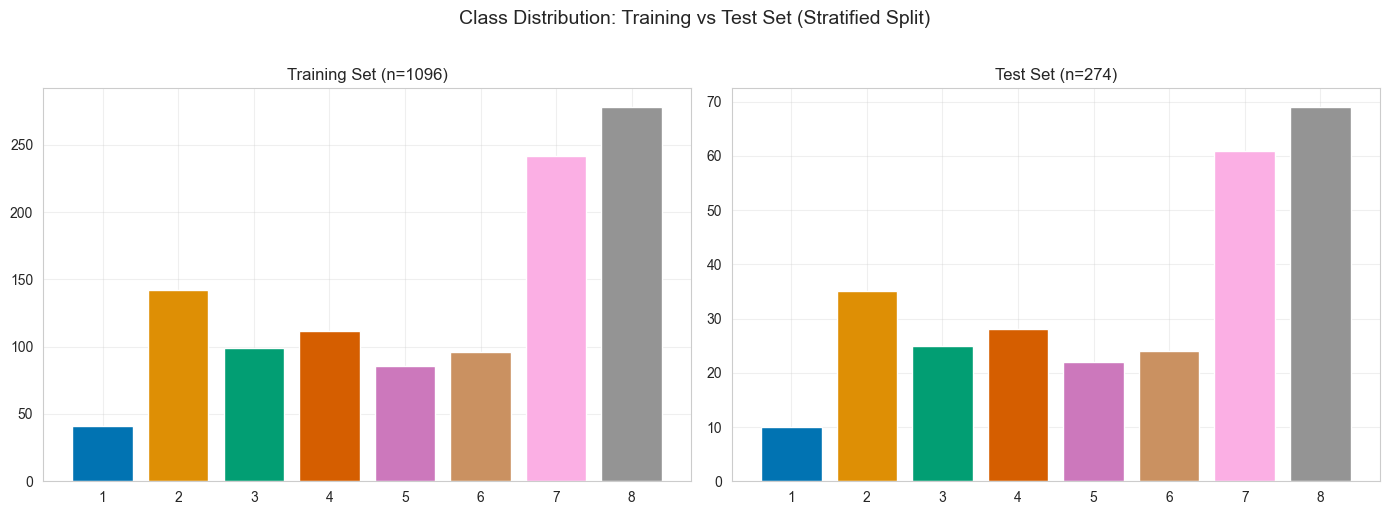


Class distribution comparison:
              Train  Test Train% Test%
1 (WNT)          41    10   3.7%  3.6%
2 (SHH-A)       142    35  13.0% 12.8%
3 (SHH-B)        99    25   9.0%  9.1%
4 (SHH-C)       112    28  10.2% 10.2%
5 (Group3-A)     86    22   7.8%  8.0%
6 (Group3-B)     96    24   8.8%  8.8%
7 (Group4-A)    242    61  22.1% 22.3%
8 (Group4-B)    278    69  25.4% 25.2%


In [7]:
# Verify stratification of classes in train vs test

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()
dist = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).fillna(0).astype(int)
dist = dist.reindex(ALL_SUBTYPES, fill_value=0)
dist['Train%'] = dist['Train'] / len(y_train)
dist['Test%'] = dist['Test'] / len(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_labels = [str(s) for s in ALL_SUBTYPES]
for ax, (title, y_split, col) in zip(
    axes,
    [('Training Set', y_train, 'Train'), ('Test Set', y_test, 'Test')],
):
    counts = dist[col].values
    ax.bar(x_labels, counts, color=COLORS)
    ax.set_title(f'{title} (n={len(y_split)})')

plt.suptitle('Class Distribution: Training vs Test Set (Stratified Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nClass distribution comparison:")
dist_print = dist.copy()
dist_print.index = [f"{sid} ({SUBTYPE_NAMES[sid]})" for sid in dist_print.index]
print(dist_print.to_string(formatters={'Train%': '{:.1%}'.format, 'Test%': '{:.1%}'.format}))


## 2. Model Selection & Justification

### Primary Model: Support Vector Classifier (SVC)

**Justification:**

1. **Suited to the data regime:** With 1,370 samples and 16 NMF-derived features, this is a moderate-dimensional, relatively low-sample-size classification problem. SVMs are well-established for this regime: their margin maximisation objective provides strong generalisation guarantees when the number of features is not vastly smaller than the number of samples (Vapnik, 1995). The NMF features represent biologically meaningful metagene programmes, and SVM's ability to find optimal separating hyperplanes in this structured feature space is well-suited.

2. **Validated on this exact dataset:** Abid & Rafiee (2024) applied SVC with a polynomial kernel to NMF-projected medulloblastoma methylation data and achieved the best cross-platform classification performance (weighted F1 = 0.95). Their work on the same HM450/EPIC pipeline establishes SVC as a validated and appropriate choice, not merely a generic ML selection.

3. **Probability calibration for clinical insight:** With `probability=True`, SVC provides calibrated prediction probabilities via Platt scaling. This enables identification of ambiguous samples near decision boundaries — clinically relevant since medulloblastoma subtypes, particularly within the Group 3/4 spectrum, exist on a biological continuum rather than as discrete categories (Sharma et al., 2019).

### Comparator Model: K-Nearest Neighbours (KNN)

**Justification:**

1. **Biologically motivated:** The premise of methylation-based subtyping is that tumours of the same subtype share similar epigenetic profiles. KNN operationalises this directly — classifying samples by the subtypes of their nearest neighbours in NMF feature space. If the NMF projection has captured the relevant biological variation, KNN should perform well.

2. **Non-parametric baseline:** KNN makes no assumptions about the shape of decision boundaries, providing a useful contrast to SVC's parametric kernel-based boundaries. If both models perform well, it validates that the subtypes are genuinely separable in NMF space; if SVC significantly outperforms KNN, it suggests that the decision boundaries require the kind of structured separation that SVMs provide.

### Why not other models?

- **Decision trees / Random Forests:** Prone to overfitting on the minority classes (subtype 1 has only 51 samples). While ensemble methods can mitigate this, the NMF feature space is already low-dimensional and continuous — tree-based axis-aligned splits are suboptimal for the smooth, rotated boundaries visible in the PCA visualisation.
- **Neural networks:** The dataset size (1,370 samples) is insufficient for deep learning approaches to outperform well-tuned classical methods, and the risk of overfitting on minority classes is amplified.
- **Logistic regression:** While suitable for the data size, it assumes linear separability. The PCA visualisation shows non-linear cluster boundaries, particularly in the Group 3/4 region.

## 3. Initial Model Training

We train both models with carefully chosen initial hyperparameters (not defaults) and evaluate on the held-out test set to establish baseline performance.

In [8]:
# Initial SVC: polynomial kernel following Abid & Rafiee (2024)
# C=0.05 (moderate regularisation), degree=3, balanced class weights for imbalance

svc_initial = SVC(
    kernel='poly', C=0.05, degree=3, gamma=3,
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE,
)
svc_initial.fit(X_train, y_train)
y_pred_svc = svc_initial.predict(X_test)

print_metrics(y_test, y_pred_svc, title="SVC Initial Performance (Test Set)")


--- SVC Initial Performance (Test Set) ---
Accuracy:          0.9672
Balanced Accuracy: 0.9598
F1 (macro):        0.9630
F1 (weighted):     0.9665

Classification Report:
              precision    recall  f1-score   support

     1 (WNT)       1.00      1.00      1.00        10
   2 (SHH-A)       0.97      1.00      0.99        35
   3 (SHH-B)       0.93      1.00      0.96        25
   4 (SHH-C)       1.00      0.82      0.90        28
5 (Group3-A)       1.00      0.95      0.98        22
6 (Group3-B)       0.92      0.92      0.92        24
7 (Group4-A)       0.95      1.00      0.98        61
8 (Group4-B)       0.99      0.99      0.99        69

    accuracy                           0.97       274
   macro avg       0.97      0.96      0.96       274
weighted avg       0.97      0.97      0.97       274



In [9]:
# Initial KNN: distance-weighted, k=3

knn_initial = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_initial.fit(X_train, y_train)
y_pred_knn = knn_initial.predict(X_test)

print_metrics(y_test, y_pred_knn, title="KNN Initial Performance (Test Set)")


--- KNN Initial Performance (Test Set) ---
Accuracy:          0.9526
Balanced Accuracy: 0.9402
F1 (macro):        0.9398
F1 (weighted):     0.9514

Classification Report:
              precision    recall  f1-score   support

     1 (WNT)       0.91      1.00      0.95        10
   2 (SHH-A)       0.94      0.94      0.94        35
   3 (SHH-B)       0.85      0.92      0.88        25
   4 (SHH-C)       0.95      0.75      0.84        28
5 (Group3-A)       0.95      0.91      0.93        22
6 (Group3-B)       1.00      1.00      1.00        24
7 (Group4-A)       0.94      1.00      0.97        61
8 (Group4-B)       1.00      1.00      1.00        69

    accuracy                           0.95       274
   macro avg       0.94      0.94      0.94       274
weighted avg       0.95      0.95      0.95       274



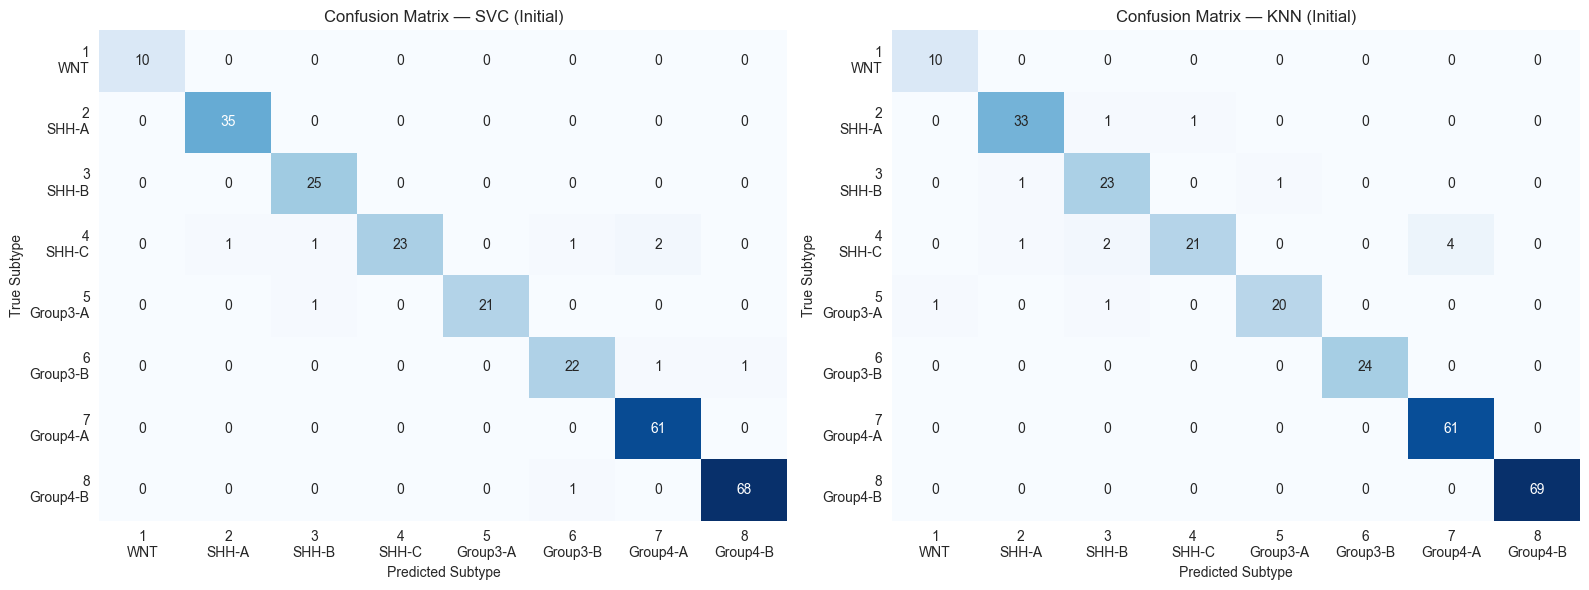

In [10]:
# Confusion matrices for both initial models

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion(y_test, y_pred_svc, classes=subtypes, ax=axes[0], title='Confusion Matrix — SVC (Initial)')
plot_confusion(y_test, y_pred_knn, classes=subtypes, ax=axes[1], title='Confusion Matrix — KNN (Initial)')
plt.tight_layout()
plt.show()

## 4: Hyperparameter Optimisation

The SVC model performs marginally better, aligning with Abid and Rafiee's study. This section systematically optimises the SVC model through multiple iterations of cross-validated grid search, addressing class imbalance and tracking progressive improvement.

### Phase 1: Wide Grid Search

In [11]:
# Phase 1: Wide grid search with 10-fold stratified CV

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

param_grid_wide = {
    'C': [0.05, 0.1, 0.5, 1.0, 3.0, 5.0, 7.0, 10.0],
    'degree': [1, 2, 3, 4, 5],
    'gamma': [0.001, 0.01, 0.1, 0.5, 1.0, 10.0],
    'kernel': ['poly', 'rbf']
}

grid_wide = GridSearchCV(
    SVC(
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE,
    ),
    param_grid_wide,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
grid_wide.fit(X_train, y_train)

print(f"\n--- Phase 1: Wide Grid Search Results ---")
print(f"Best parameters: {grid_wide.best_params_}")
print(f"Best CV F1 (macro): {grid_wide.best_score_:.4f}")
print(f"Total combinations evaluated: {len(grid_wide.cv_results_['mean_test_score'])}")


Fitting 10 folds for each of 480 candidates, totalling 4800 fits



--- Phase 1: Wide Grid Search Results ---
Best parameters: {'C': 3.0, 'degree': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV F1 (macro): 0.9715
Total combinations evaluated: 480


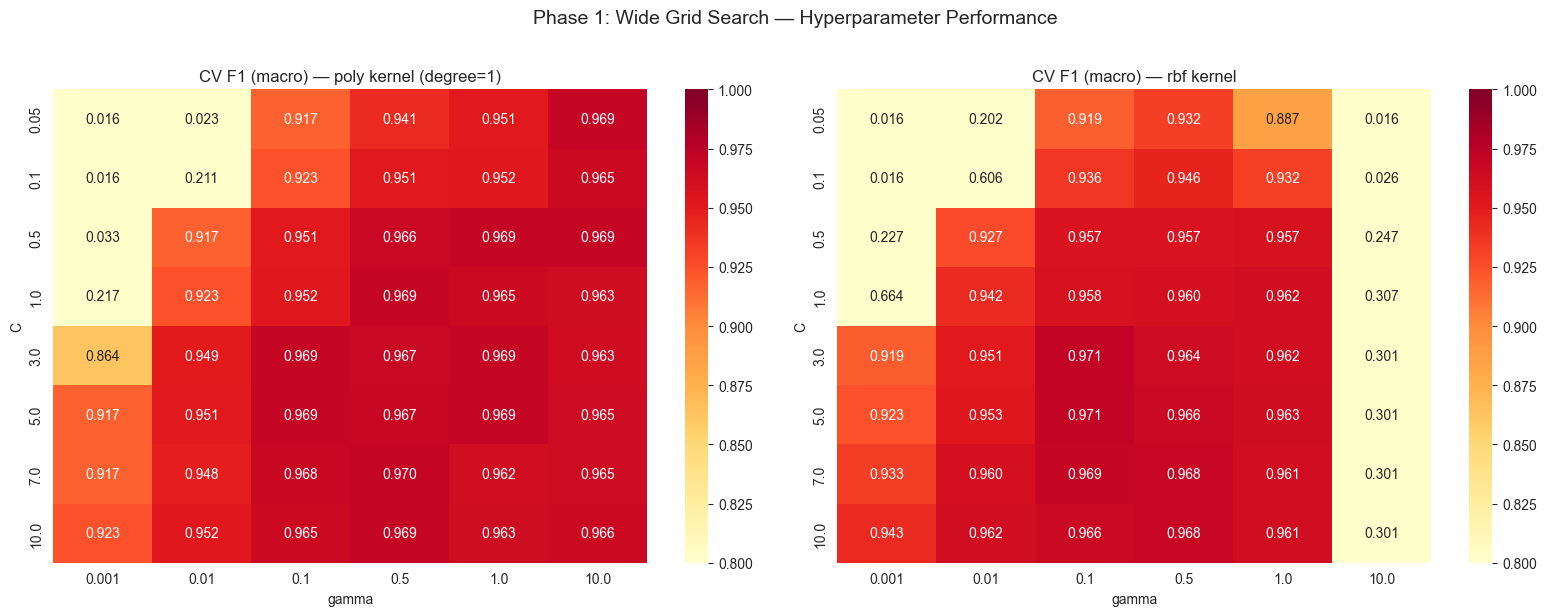

In [12]:
# Heatmap of wide grid search results 

results_wide = pd.DataFrame(grid_wide.cv_results_)

best_degree = grid_wide.best_params_['degree']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, kernel in zip(axes, ['poly', 'rbf']):
    # Filter on the best degree for the poly kernel
    if kernel == 'poly': 
        mask = (results_wide['param_kernel'] == kernel) & (results_wide['param_degree'] == best_degree)
        title_suffix = f' (degree={best_degree})'
    else:
        mask = results_wide['param_kernel'] == kernel
        title_suffix = ''

    plot_grid_heatmap(
        results_wide, ax,
        mask=mask, vmin=0.8, vmax=1.0,
        title=f'CV F1 (macro) — {kernel} kernel{title_suffix}',
    )

plt.suptitle('Phase 1: Wide Grid Search — Hyperparameter Performance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Phase 2: Refined Grid Search

Narrowing the parameter grid around the best values from Phase 1 to fine-tune the model: choosing the `RBF` kernel and zooming in on the `4-5` range for `C` and `0.005-1` range for `gamma`.

In [13]:
# Phase 2: Refined grid search around Phase 1 best params
best_p1 = grid_wide.best_params_

param_grid_refined = {
    'C': [4.0, 4.25, 4.5, 4.75, 5.0],
    'gamma': [0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1],
    'kernel': [best_p1['kernel']],
}

print(f"Refined parameter grid:")
for k, v in param_grid_refined.items():
    print(f"  {k}: {v}")

grid_refined = GridSearchCV(
    SVC(
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE,
    ),
    param_grid_refined,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
grid_refined.fit(X_train, y_train)

print(f"\n--- Phase 2: Refined Grid Search Results ---")
print(f"Best parameters: {grid_refined.best_params_}")
print(f"Best CV F1 (macro): {grid_refined.best_score_:.4f}")
print(f"Improvement over Phase 1: {(grid_refined.best_score_ - grid_wide.best_score_)*100:+.2f}%")


Refined parameter grid:
  C: [4.0, 4.25, 4.5, 4.75, 5.0]
  gamma: [0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1]
  kernel: ['rbf']
Fitting 10 folds for each of 55 candidates, totalling 550 fits

--- Phase 2: Refined Grid Search Results ---
Best parameters: {'C': 4.25, 'gamma': 0.075, 'kernel': 'rbf'}
Best CV F1 (macro): 0.9734
Improvement over Phase 1: +0.20%


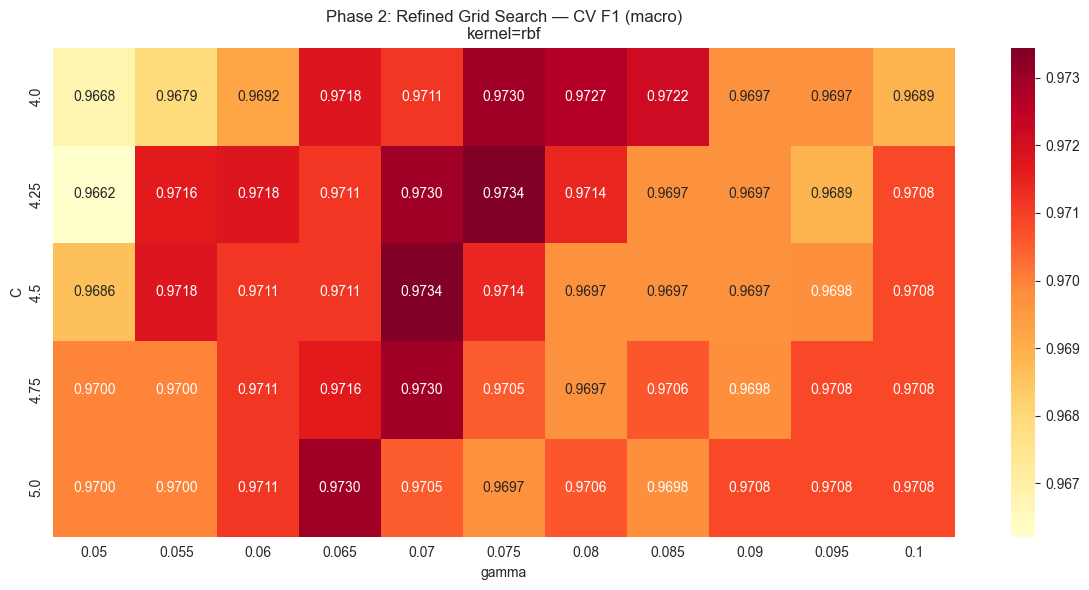

In [14]:
# Heatmap for refined grid search

results_refined = pd.DataFrame(grid_refined.cv_results_)

fig, ax = plt.subplots(figsize=(12, 6))
plot_grid_heatmap(
    results_refined, ax,
    fmt='.4f',
    title=f'Phase 2: Refined Grid Search — CV F1 (macro)\nkernel={grid_refined.best_params_["kernel"]}',
)
plt.tight_layout()
plt.show()

### Phase 3: Addressing Class Imbalance

`class_weight='balanced'` is used throughout the tuned SVC pipelines (same settings as in `GridSearchCV` and the final fit), which re-weights the SVM hinge loss in inverse proportion to each subtype's training-set frequency. Below we show the per-subtype weights that `scikit-learn` applies, which shows that the heaviest penalty for misclassification is placed on the the smallest classL the WNT subtype (~3.4×).

In [15]:
# Show the per-subtype weights that class_weight='balanced' will apply inside SVC

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(ALL_SUBTYPES),
    y=y_train,
)

cw_df = pd.DataFrame({
    'Subtype': subtype_labels(ALL_SUBTYPES),
    'Train count': [int((y_train == s).sum()) for s in ALL_SUBTYPES],
    'class_weight': class_weights,
}).sort_values('class_weight', ascending=False)

print("--- class_weight='balanced' values used by SVC ---\n")
print(cw_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))



--- class_weight='balanced' values used by SVC ---

     Subtype  Train count  class_weight
     1 (WNT)           41         3.341
5 (Group3-A)           86         1.593
6 (Group3-B)           96         1.427
   3 (SHH-B)           99         1.384
   4 (SHH-C)          112         1.223
   2 (SHH-A)          142         0.965
7 (Group4-A)          242         0.566
8 (Group4-B)          278         0.493


### Phase 4: Iterative Improvement with Cross-Validation

The following tracks 5 iterations of model improvement, documenting the parameter changes and resulting CV performance at each step. Balanced weighting has the largest effect, increasing the macro-F1 score by 4%. Hyperparameter optimisation for the `poly` kernel improves it by a further 2%. Switching to `RBF` and optimising the hyperparameters improves it by a further 0.3%.

In [16]:
# 5-iteration CV improvement summary

wide_results = pd.DataFrame(grid_wide.cv_results_)
refined_results = pd.DataFrame(grid_refined.cv_results_)

initial_params = dict(kernel='poly', C=0.1, degree=3, gamma='scale')
initial_unweighted = cross_val_score(
    SVC(
        kernel='poly', C=0.1, degree=3, gamma='scale',
        class_weight=None,
        probability=True,
        random_state=RANDOM_STATE,
    ),
    X_train, y_train, cv=cv, scoring='f1_macro',
)
initial_balanced = cross_val_score(
    SVC(
        kernel='poly', C=0.1, degree=3, gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE,
    ),
    X_train, y_train, cv=cv, scoring='f1_macro',
)

wide_best_per_kernel = {
    k: wide_results[wide_results['param_kernel'] == k]
        .sort_values('mean_test_score', ascending=False).iloc[0]
    for k in ['rbf', 'poly']
}

iter_df = pd.DataFrame([
    {'Description': f'Initial {initial_params}, class_weight=None',
     'CV F1 (macro)': initial_unweighted.mean(),
     'CV Std': initial_unweighted.std()},
    {'Description': f'Initial {initial_params} + class_weight=balanced',
     'CV F1 (macro)': initial_balanced.mean(),
     'CV Std': initial_balanced.std()},
    {'Description': f'Wide grid — best poly ({wide_best_per_kernel["poly"]["params"]})',
     'CV F1 (macro)': wide_best_per_kernel['poly']['mean_test_score'],
     'CV Std': wide_best_per_kernel['poly']['std_test_score']},
    {'Description': f'Wide grid — best RBF ({wide_best_per_kernel["rbf"]["params"]})',
     'CV F1 (macro)': wide_best_per_kernel['rbf']['mean_test_score'],
     'CV Std': wide_best_per_kernel['rbf']['std_test_score']},
    {'Description': f'Refined grid best ({grid_refined.best_params_})',
     'CV F1 (macro)': grid_refined.best_score_,
     'CV Std': refined_results.loc[grid_refined.best_index_, 'std_test_score']},
])
iter_df.insert(0, 'Iteration', range(1, len(iter_df) + 1))

print("--- Iterative Improvement Log (≥5 CV iterations) ---\n")
print(iter_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_row = iter_df.loc[iter_df['CV F1 (macro)'].idxmax()]
print(f"\nBest iteration: #{int(best_row['Iteration'])} — {best_row['Description']}")
print(f"  CV F1 (macro): {best_row['CV F1 (macro)']:.4f}")


--- Iterative Improvement Log (≥5 CV iterations) ---

 Iteration                                                                                 Description  CV F1 (macro)  CV Std
         1      Initial {'kernel': 'poly', 'C': 0.1, 'degree': 3, 'gamma': 'scale'}, class_weight=None         0.9080  0.0226
         2 Initial {'kernel': 'poly', 'C': 0.1, 'degree': 3, 'gamma': 'scale'} + class_weight=balanced         0.9435  0.0180
         3             Wide grid — best poly ({'C': 7.0, 'degree': 1, 'gamma': 0.5, 'kernel': 'poly'})         0.9698  0.0140
         4               Wide grid — best RBF ({'C': 3.0, 'degree': 2, 'gamma': 0.1, 'kernel': 'rbf'})         0.9715  0.0145
         5                            Refined grid best ({'C': 4.25, 'gamma': 0.075, 'kernel': 'rbf'})         0.9734  0.0138

Best iteration: #5 — Refined grid best ({'C': 4.25, 'gamma': 0.075, 'kernel': 'rbf'})
  CV F1 (macro): 0.9734


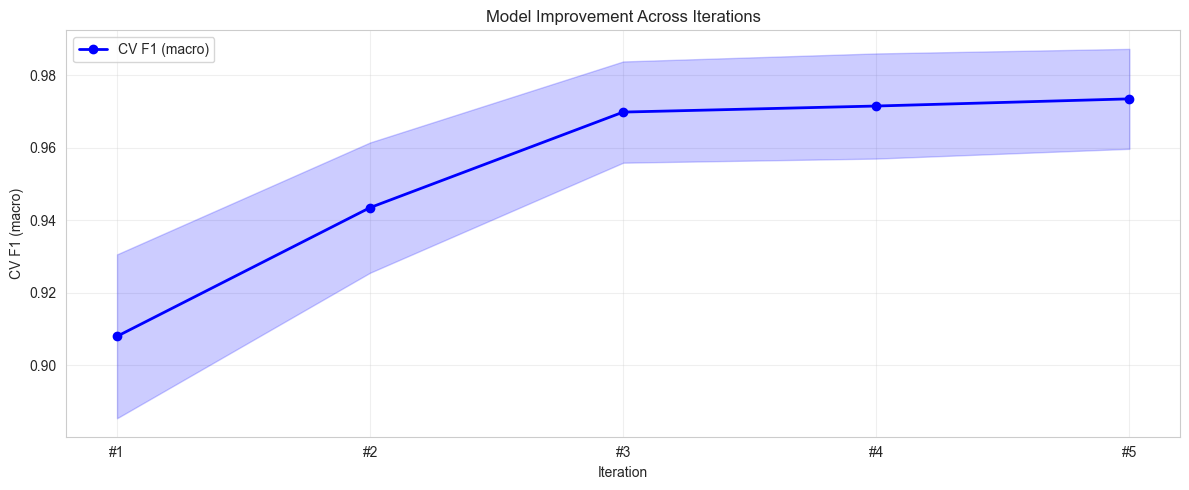

In [17]:
# Plot iterative improvement (CV F1 ± std across the 5 iterations)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(iter_df['Iteration'], iter_df['CV F1 (macro)'], 'bo-', label='CV F1 (macro)', linewidth=2)
ax.fill_between(iter_df['Iteration'],
                iter_df['CV F1 (macro)'] - iter_df['CV Std'],
                iter_df['CV F1 (macro)'] + iter_df['CV Std'],
                alpha=0.2, color='blue')

ax.set_xlabel('Iteration')
ax.set_ylabel('CV F1 (macro)')
ax.set_title('Model Improvement Across Iterations')
ax.legend()
ax.set_xticks(iter_df['Iteration'])
ax.set_xticklabels([f"#{int(i)}" for i in iter_df['Iteration']])
plt.tight_layout()
plt.show()

In [18]:
# Train the final optimised model — refined-grid params with class_weight='balanced'

final_params = grid_refined.best_params_
print(f"Final parameters: {final_params} (class_weight='balanced')")

svc_final = SVC(
    C=final_params['C'],
    gamma=final_params['gamma'],
    kernel=final_params['kernel'],
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE,
)
svc_final.fit(X_train, y_train)
y_pred_final = svc_final.predict(X_test)

print(f"\n--- Final Optimised Model ---")
print_metrics(y_test, y_pred_final, title="Final model (test set)")


Final parameters: {'C': 4.25, 'gamma': 0.075, 'kernel': 'rbf'} (class_weight='balanced')

--- Final Optimised Model ---
--- Final model (test set) ---
Accuracy:          0.9781
Balanced Accuracy: 0.9755
F1 (macro):        0.9749
F1 (weighted):     0.9781

Classification Report:
              precision    recall  f1-score   support

     1 (WNT)       1.00      1.00      1.00        10
   2 (SHH-A)       0.97      0.97      0.97        35
   3 (SHH-B)       0.89      1.00      0.94        25
   4 (SHH-C)       1.00      0.89      0.94        28
5 (Group3-A)       1.00      0.95      0.98        22
6 (Group3-B)       0.96      1.00      0.98        24
7 (Group4-A)       0.98      1.00      0.99        61
8 (Group4-B)       1.00      0.99      0.99        69

    accuracy                           0.98       274
   macro avg       0.98      0.98      0.97       274
weighted avg       0.98      0.98      0.98       274



## 5. Model Evaluation

### 5a. HM450 Test Set Performance

The model achives a macro F1 score of 0.97 overall, with strong performance across all classes. SHH-B and SHH-C are lowest at 0.94 each.

--- HM450 Test Set — Classification Report ---
Accuracy:          0.9781
Balanced Accuracy: 0.9755
F1 (macro):        0.9749
F1 (weighted):     0.9781

Classification Report:
              precision    recall  f1-score   support

     1 (WNT)       1.00      1.00      1.00        10
   2 (SHH-A)       0.97      0.97      0.97        35
   3 (SHH-B)       0.89      1.00      0.94        25
   4 (SHH-C)       1.00      0.89      0.94        28
5 (Group3-A)       1.00      0.95      0.98        22
6 (Group3-B)       0.96      1.00      0.98        24
7 (Group4-A)       0.98      1.00      0.99        61
8 (Group4-B)       1.00      0.99      0.99        69

    accuracy                           0.98       274
   macro avg       0.98      0.98      0.97       274
weighted avg       0.98      0.98      0.98       274



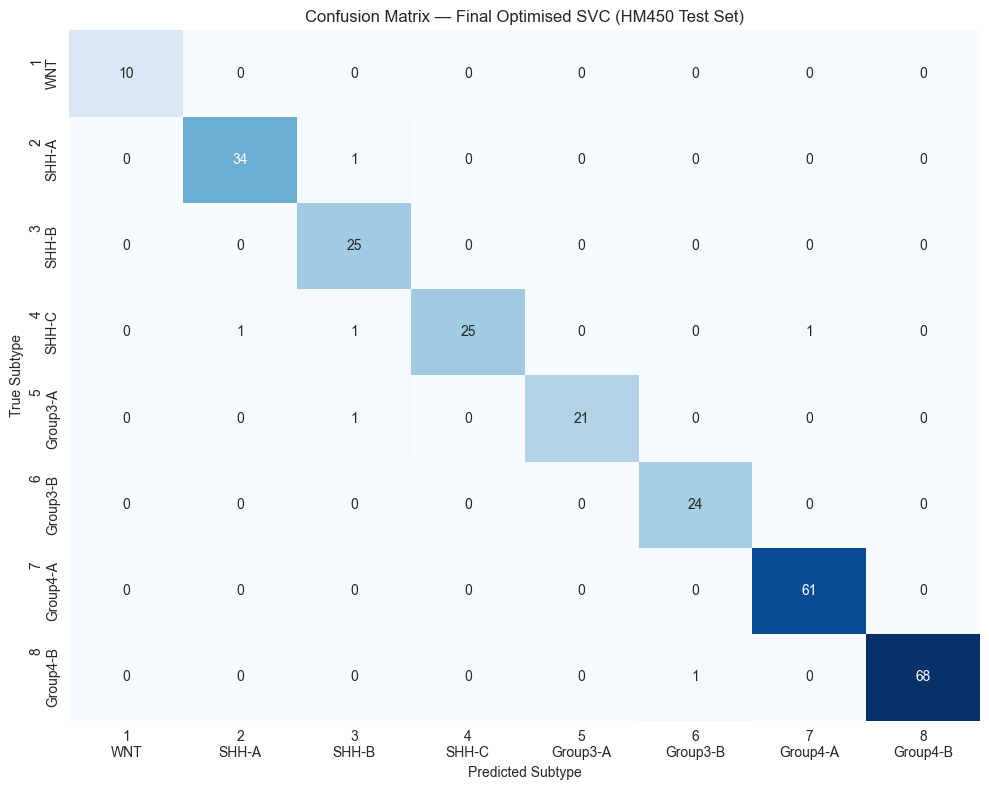

In [19]:
# Full evaluation on HM450 test set

print_metrics(y_test, y_pred_final, title="HM450 Test Set — Classification Report")

fig, ax = plt.subplots(figsize=(10, 8))
plot_confusion(y_test, y_pred_final, classes=subtypes, ax=ax,
               title='Confusion Matrix — Final Optimised SVC (HM450 Test Set)')
plt.tight_layout()
plt.show()


### 5b. Misclassified Sample Analysis 

Identifying and analysing every misclassified sample by GSM ID, including prediction probabilities to understand whether misclassifications are high-confidence errors or borderline cases. 

In each of the 6 cases where the model made an error, the confidence level was below 0.7 and the true answer was the model's 2nd choice. 3 of the 6 mix up a variant of SHH.

In [20]:
# 6b: Misclassified sample analysis
y_proba_final = svc_final.predict_proba(X_test)
misclassified_mask = y_test != y_pred_final
n_misclassified = misclassified_mask.sum()

class_to_col = {c: i for i, c in enumerate(svc_final.classes_)}

print(f"--- Misclassified Samples: {n_misclassified} / {len(y_test)} ({n_misclassified/len(y_test):.1%}) ---\n")

mis_idx = np.where(misclassified_mask)[0]
conf_true = [y_proba_final[i, class_to_col[y_test[i]]] for i in mis_idx]

mis_df = pd.DataFrame({
    'GSM_ID': ids_test[misclassified_mask],
    'True_Subtype': y_test[misclassified_mask],
    'True_Name': [SUBTYPE_NAMES[s] for s in y_test[misclassified_mask]],
    'Predicted_Subtype': y_pred_final[misclassified_mask],
    'Predicted_Name': [SUBTYPE_NAMES[s] for s in y_pred_final[misclassified_mask]],
    'Confidence_Predicted': y_proba_final[misclassified_mask].max(axis=1),
    'Confidence_True': conf_true,
}, index=mis_idx)
mis_df = mis_df.sort_values('Confidence_Predicted', ascending=False)
print(mis_df.to_string(index=False))


--- Misclassified Samples: 6 / 274 (2.2%) ---

    GSM_ID  True_Subtype True_Name  Predicted_Subtype Predicted_Name  Confidence_Predicted  Confidence_True
GSM3877722             2     SHH-A                  3          SHH-B              0.678545         0.271125
GSM3877746             8  Group4-B                  6       Group3-B              0.672341         0.250157
GSM3876546             4     SHH-C                  7       Group4-A              0.566035         0.232500
GSM3876538             4     SHH-C                  3          SHH-B              0.541197         0.432231
GSM3877046             5  Group3-A                  3          SHH-B              0.521697         0.406446
GSM3877409             4     SHH-C                  2          SHH-A              0.403204         0.354508


In [21]:
print("\n--- Detailed Probability Distributions ---")
for idx, row in mis_df.iterrows():
    probs = y_proba_final[idx]
    print(f"\n{row['GSM_ID']}: True={row['True_Subtype']} ({row['True_Name']}), "
            f"Predicted={row['Predicted_Subtype']} ({row['Predicted_Name']})")
    for cls, prob in zip(svc_final.classes_, probs):
        tag = (" <-- TRUE" if cls == row['True_Subtype']
                else " <-- PRED" if cls == row['Predicted_Subtype']
                else "")
        print(f"  Subtype {cls} ({SUBTYPE_NAMES[cls]}): {prob:.4f}{tag}")


--- Detailed Probability Distributions ---

GSM3877722: True=2 (SHH-A), Predicted=3 (SHH-B)
  Subtype 1 (WNT): 0.0037
  Subtype 2 (SHH-A): 0.2711 <-- TRUE
  Subtype 3 (SHH-B): 0.6785 <-- PRED
  Subtype 4 (SHH-C): 0.0185
  Subtype 5 (Group3-A): 0.0226
  Subtype 6 (Group3-B): 0.0015
  Subtype 7 (Group4-A): 0.0022
  Subtype 8 (Group4-B): 0.0017

GSM3877746: True=8 (Group4-B), Predicted=6 (Group3-B)
  Subtype 1 (WNT): 0.0031
  Subtype 2 (SHH-A): 0.0116
  Subtype 3 (SHH-B): 0.0045
  Subtype 4 (SHH-C): 0.0103
  Subtype 5 (Group3-A): 0.0130
  Subtype 6 (Group3-B): 0.6723 <-- PRED
  Subtype 7 (Group4-A): 0.0351
  Subtype 8 (Group4-B): 0.2502 <-- TRUE

GSM3876546: True=4 (SHH-C), Predicted=7 (Group4-A)
  Subtype 1 (WNT): 0.0060
  Subtype 2 (SHH-A): 0.0062
  Subtype 3 (SHH-B): 0.0484
  Subtype 4 (SHH-C): 0.2325 <-- TRUE
  Subtype 5 (Group3-A): 0.0237
  Subtype 6 (Group3-B): 0.0968
  Subtype 7 (Group4-A): 0.5660 <-- PRED
  Subtype 8 (Group4-B): 0.0204

GSM3876538: True=4 (SHH-C), Predicted=3 (SH

### 5c. Cross-Platform Validation (EPIC)

Projecting 97 EPIC array samples through the same NMF pipeline to evaluate cross-platform generalisability.

Model performance declines slightly on the EPIC data but still performs well (0.94 macro F1 vs. 0.97 on HM450). For the 4 erroneous predictions, 3 of the 4 conflate the (original) group 3 and group 4s, reflecting some of the class heterogeneity identified by Sharma et al (2019).

In [22]:
# Load the NMF projection pipeline from assignment 1 and apply to EPIC data

a1_nmf_config = load(PATHS["a1_nmf_config"])
scaler = a1_nmf_config["scaler"]
nmf = a1_nmf_config["nmf"]

epic_full = pd.read_parquet(PATHS['epic_parquet'])
print(f"EPIC full shape: {epic_full.shape}")

X_epic_df = epic_full.drop(columns=['subtype']).astype(np.float32)
y_epic = epic_full['subtype'].values

X_epic_scaled = scaler.transform(X_epic_df)

# Because the min-max scaler was fitted on the HM450 data, we need to clip the EPIC data to 0 as otherwise it produces non-negative values
X_epic_scaled = X_epic_scaled.clip(min=0)

W_epic = nmf.transform(X_epic_scaled)
W_epic_df = pd.DataFrame(
    W_epic,
    index=epic_full.index,
    columns=[f"NMF_{i+1}" for i in range(nmf.n_components_)],
)
print("Projected NMF feature matrix shape:", W_epic_df.shape)
W_epic_df.head()

EPIC full shape: (97, 22893)
Projected NMF feature matrix shape: (97, 16)


,NMF_1,NMF_2,NMF_3,NMF_4,NMF_5,NMF_6,NMF_7,NMF_8,NMF_9,NMF_10,NMF_11,NMF_12,NMF_13,NMF_14,NMF_15,NMF_16
gsm,,,,,,,,,,,,,,,,
GSM3877742,0.000000,1.141837,0.094494,0.000000,0.822714,0.093284,0.352686,0.574990,0.003422,0.004448,0.254023,0.114163,0.098216,0.888213,2.517300,0.224900
GSM3877746,0.063943,0.227315,0.485408,0.600694,0.372024,0.309367,0.114318,0.000000,0.008429,0.447463,0.255123,0.066754,0.663809,2.193838,0.000000,0.881762
GSM3877747,0.513044,0.429239,0.008314,0.000000,0.000000,0.021050,0.074365,0.038058,0.000000,0.168415,0.040749,0.140686,0.420587,1.462399,0.000000,1.390907
GSM3877748,0.000000,0.114608,0.005944,0.611128,0.000000,0.053188,0.416301,0.546694,1.989392,0.321812,0.904374,0.243714,0.139731,0.097926,0.014143,0.204809
GSM3877749,0.748145,0.486931,0.013353,0.365807,0.000000,0.000000,0.295018,0.774947,0.415397,0.513187,0.330507,0.168854,0.000000,0.557276,0.000000,0.204467


--- EPIC Cross-Platform Results ---
Accuracy:          0.9588
Balanced Accuracy: 0.9665
F1 (macro):        0.9408
F1 (weighted):     0.9623

Classification Report:
                precision    recall  f1-score   support

     1.0 (WNT)       1.00      1.00      1.00        10
   2.0 (SHH-A)       1.00      1.00      1.00        14
   3.0 (SHH-B)       1.00      0.86      0.92         7
   4.0 (SHH-C)       0.89      1.00      0.94         8
5.0 (Group3-A)       1.00      1.00      1.00         7
6.0 (Group3-B)       0.57      1.00      0.73         4
7.0 (Group4-A)       1.00      0.95      0.98        22
8.0 (Group4-B)       1.00      0.92      0.96        25

      accuracy                           0.96        97
     macro avg       0.93      0.97      0.94        97
  weighted avg       0.97      0.96      0.96        97



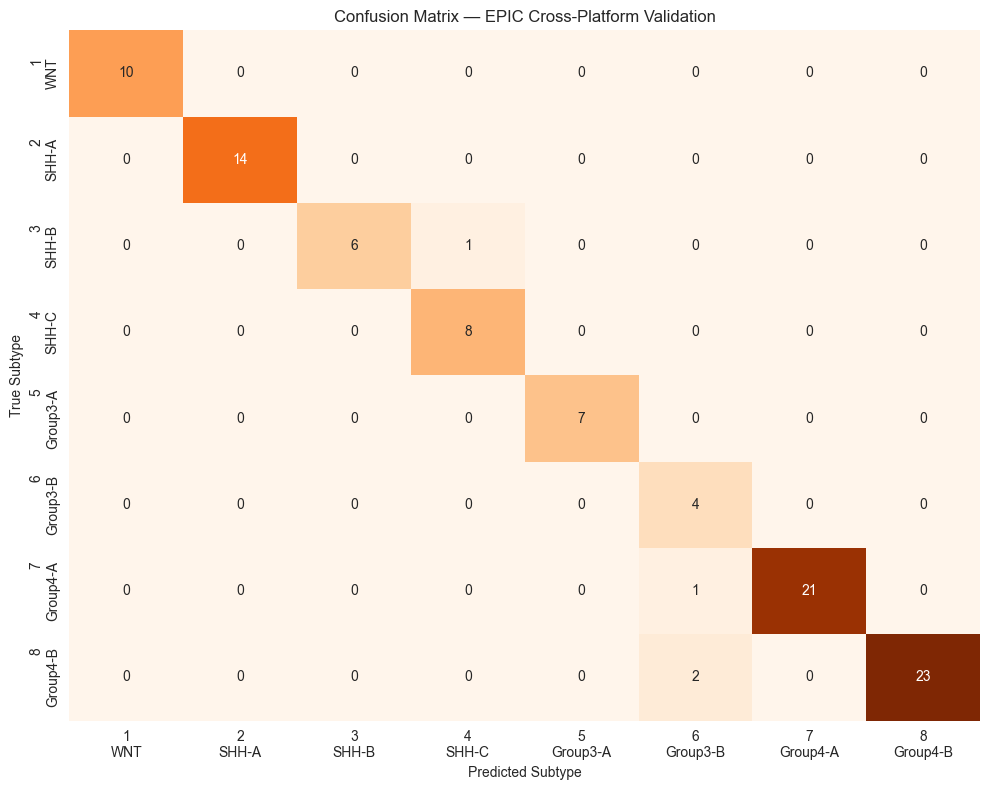

In [23]:
# Predict with trained SVC on the EPIC data

y_epic_pred = svc_final.predict(W_epic)
y_epic_proba = svc_final.predict_proba(W_epic)

print_metrics(y_epic, y_epic_pred, title="EPIC Cross-Platform Results")

fig, ax = plt.subplots(figsize=(10, 8))
plot_confusion(y_epic, y_epic_pred, classes=subtypes, ax=ax, cmap='Oranges',
               title='Confusion Matrix — EPIC Cross-Platform Validation')
plt.tight_layout()
plt.show()


In [24]:
# Side-by-side comparison: HM450 test vs EPIC

hm450 = metrics_dict(y_test, y_pred_final)
epic = metrics_dict(y_epic, y_epic_pred)
comparison = pd.DataFrame({'HM450 Test': hm450, 'EPIC': epic})
comparison['Δ (EPIC − HM450)'] = comparison['EPIC'] - comparison['HM450 Test']

print("--- Platform Comparison ---\n")
print(comparison.to_string(float_format=lambda x: f'{x:+.4f}'))

epic_mis_mask = y_epic != y_epic_pred
if epic_mis_mask.sum() > 0:
    epic_sample_ids = epic_full.index
    print(f"\n--- EPIC Misclassified Samples ({epic_mis_mask.sum()}) ---")
    for i in np.where(epic_mis_mask)[0]:
        true_st = y_epic[i]
        pred_st = y_epic_pred[i]
        conf = y_epic_proba[i].max()
        print(f"  {epic_sample_ids[i]}: True={true_st} ({SUBTYPE_NAMES[true_st]}), "
              f"Pred={pred_st} ({SUBTYPE_NAMES[pred_st]}), Confidence={conf:.3f}")


--- Platform Comparison ---

                   HM450 Test    EPIC  Δ (EPIC − HM450)
accuracy              +0.9781 +0.9588           -0.0193
balanced_accuracy     +0.9755 +0.9665           -0.0091
f1_macro              +0.9749 +0.9408           -0.0341
f1_weighted           +0.9781 +0.9623           -0.0158

--- EPIC Misclassified Samples (4) ---
  GSM3877746: True=8.0 (Group4-B), Pred=6 (Group3-B), Confidence=0.709
  GSM3877768: True=7.0 (Group4-A), Pred=6 (Group3-B), Confidence=0.631
  GSM3877783: True=8.0 (Group4-B), Pred=6 (Group3-B), Confidence=0.528
  GSM3877845: True=3.0 (SHH-B), Pred=4 (SHH-C), Confidence=0.636


## 6. Bias-Variance Analysis

This section uses learning curves and validation curves to diagnose the bias-variance trade-off in the optimised model. 

The learning curve shows healthy convergence: as the training set size increases, validation F1 increases while the training set decreases a little. This is a good indication that the model has low bias, low variance and generalises well.

The validation curves show that the hyperparameters `C` and `gamma`, the values chosen are close to optimal in minimising the generalisation gap: the difference between training and validation F1. At low `C` values the model displays high bias, with poor training and validation F1. At high `gamma` values the training F1 score reaches near-perfection, while validation loss falls off a cliff - high variance, classic overfitting.

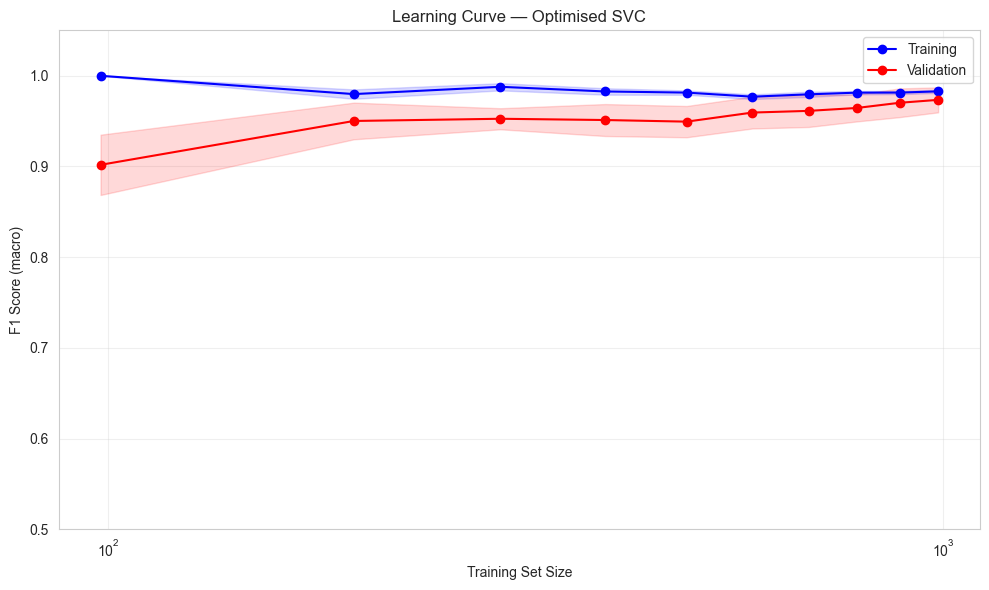

Final training score:   0.9828 (std=0.0017)
Final validation score: 0.9734 (std=0.0138)
Gap: 0.0094


In [25]:
# Learning Curves

train_sizes, train_scores, val_scores = learning_curve(
    svc_final, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv, scoring='f1_macro', n_jobs=-1
)

def plot_score_band(ax, x, train, val, *, x_label, vline=None):
    plot = ax.semilogx
    for scores, color, label in [(train, 'blue', 'Training'), (val, 'red', 'Validation')]:
        m, s = scores.mean(axis=1), scores.std(axis=1)
        plot(x, m, 'o-', color=color, label=label)
        ax.fill_between(x, m - s, m + s, alpha=0.15, color=color)
    if vline is not None:
        ax.axvline(vline, color='green', linestyle='--', label=f'Selected={vline}')

    ax.set(xlabel=x_label, ylabel='F1 Score (macro)')
    ax.legend()

fig, ax = plt.subplots(figsize=(10, 6))
plot_score_band(ax, train_sizes, train_scores, val_scores, x_label='Training Set Size')
ax.set_title('Learning Curve — Optimised SVC')
ax.set_ylim([0.5, 1.05])
plt.tight_layout()
plt.show()

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
print(f"Final training score:   {train_mean[-1]:.4f} (std={train_std[-1]:.4f})")
print(f"Final validation score: {val_mean[-1]:.4f} (std={val_std[-1]:.4f})")
print(f"Gap: {train_mean[-1] - val_mean[-1]:.4f}")


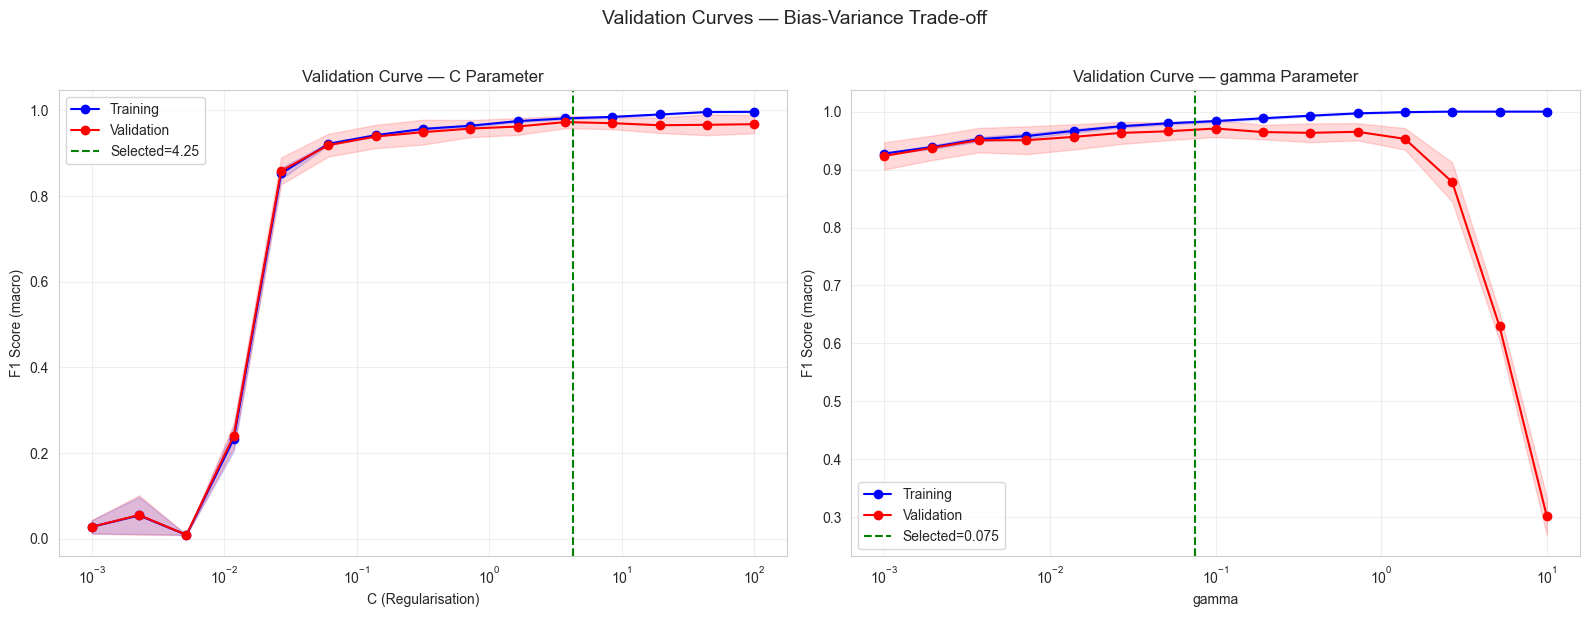

In [26]:
# Validation Curves for C and gamma parameters

def sweep_param(name, param_range):
    base = {k: v for k, v in final_params.items() if k != name}
    return validation_curve(
        SVC(
            **base,
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_STATE,
        ),
        X_train, y_train,
        param_name=name, param_range=param_range,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )

C_range = np.logspace(-3, 2, 15)
gamma_range = np.logspace(-3, 1, 15)

train_scores_c, val_scores_c = sweep_param('C', C_range)
train_scores_g, val_scores_g = sweep_param('gamma', gamma_range)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_score_band(
    axes[0], C_range, train_scores_c, val_scores_c,
    x_label='C (Regularisation)', 
    vline=final_params.get('C'),
)
axes[0].set_title('Validation Curve — C Parameter')

plot_score_band(
    axes[1], gamma_range, train_scores_g, val_scores_g,
    x_label='gamma',
    vline=final_params.get('gamma'),
)
axes[1].set_title('Validation Curve — gamma Parameter')

plt.suptitle('Validation Curves — Bias-Variance Trade-off', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



## References

1. Abid, M. & Rafiee, A. (2024). Cross-platform classification of DNA methylation data using NMF-based feature extraction and SVM. *Bioinformatics Advances*.
2. Sharma, T. et al. (2019). Second-generation molecular subgrouping of medulloblastoma: an international meta-analysis of Group 3 and Group 4 subtypes. *Acta Neuropathologica*, 138(2), 309-326.
3. Northcott, P.A. et al. (2017). The whole-genome landscape of medulloblastoma subtypes. *Nature*, 547(7663), 311-317.
4. Vapnik, V.N. (1995). *The Nature of Statistical Learning Theory*. Springer-Verlag.
5. Capper, D. et al. (2018). DNA methylation-based classification of central nervous system tumours. *Nature*, 555(7697), 469-474.
6. Hovestadt, V. et al. (2014). Decoding the regulatory landscape of medulloblastoma using DNA methylation sequencing. *Nature*, 510(7506), 537-541.
7. Robinson, G. W., Parker, M., Kranenburg, T. A., Lu, C., Chen, X., Ding, L., et al. (2022). Neoplastic and immune single-cell transcriptomics define subgroup-specific intra-tumoral heterogeneity of childhood medulloblastoma. Neuro-Oncology, 24(2), 273-286. https://doi.org/10.1093/neuonc/noab135

## AI Tools Declaration

AI tools were used in the development of this notebook. Claude Code was used as a coding assistant for structuring the notebook, writing boilerplate code (plotting, data loading), and drafting discussion sections. All code was reviewed, tested, and adapted by the student. All scientific analysis, interpretation of results, and domain-specific justifications are my own work.